In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/superstore_data.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11.25


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [7]:
!pip install prophet

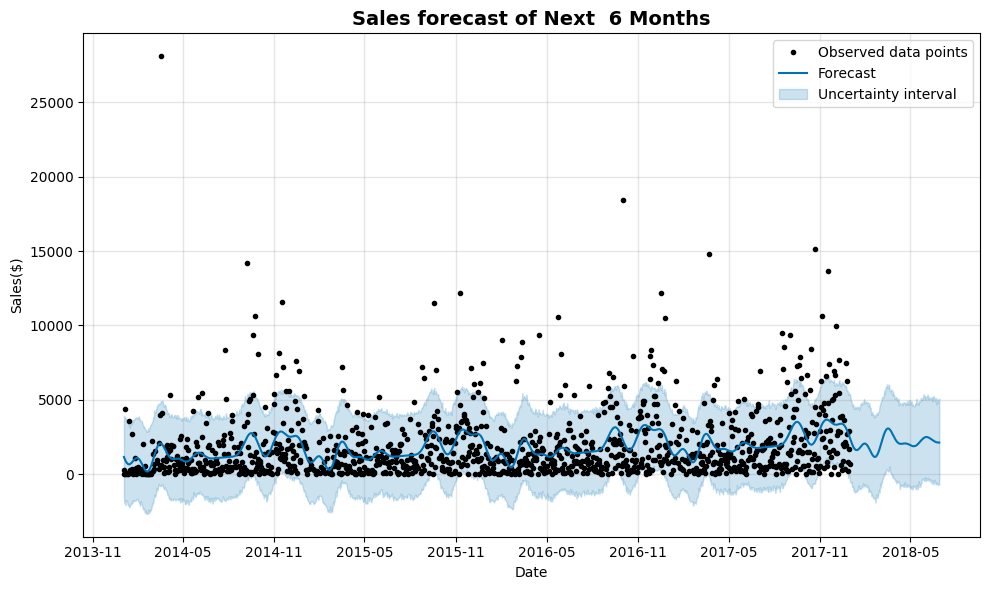

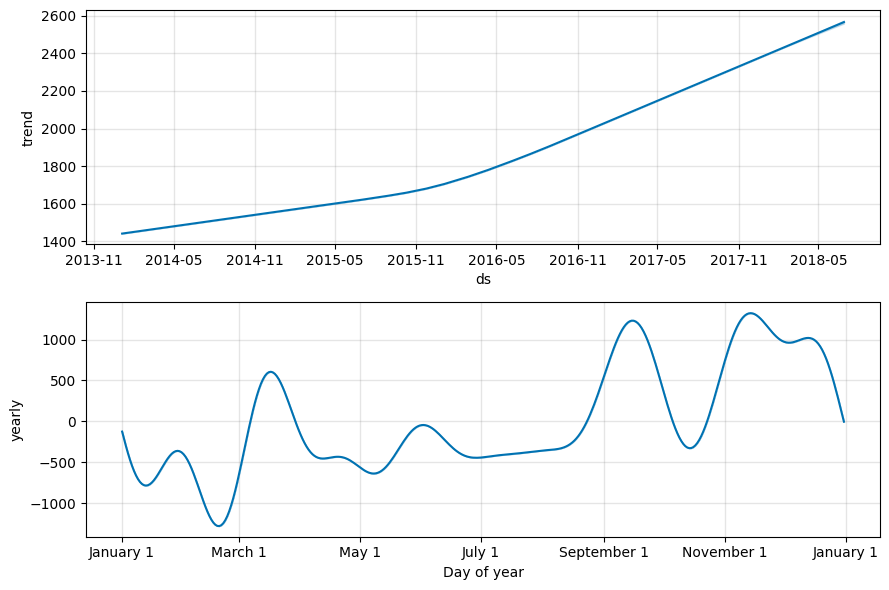

In [10]:
from prophet import Prophet
#Prepare The Data
monthly=df.groupby('Order Date')['Sales'].sum().reset_index()
monthly.columns=['ds','y']

#Train Model
model=Prophet(yearly_seasonality=True,
              weekly_seasonality= False,
              daily_seasonality=False)
model.fit(monthly)

#Forecast 6 months
future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)

#Plot
model.plot(forecast)
plt.title("Sales forecast of Next  6 Months",fontweight='bold',fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales($)')
plt.legend()
plt.tight_layout()
plt.show()

#Seasonality Components
model.plot_components(forecast)
plt.tight_layout()
plt.show()

#Profit Prediction Model (Random Forest)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder

#copy the df
df_ml=df.copy()

#Target Variable -Is Profitable
df_ml['Is_profitable'] = (df_ml['Profit']>0).astype(int)

#Encoding the categorical columns
cat_cols=['Region', 'Category', 'Sub-Category', 'Segment', 'Ship Mode']
le = LabelEncoder()
for i in cat_cols:
  df_ml[i]=le.fit_transform(df_ml[i])

#Features And Target
features = ['Sales', 'Quantity', 'Discount',
            'Region', 'Category', 'Sub-Category',
            'Segment', 'Ship Mode']
X=df_ml[features]
y=df_ml['Is_profitable']

#Train Test splitng
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Training the Model
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#Results
y_pred=rf_model.predict(X_test)
print("="*50)
print("Random Forest Model Performance ")
print("="*50)
print(classification_report(y_test,y_pred))
print("="*50)
print(f"Accuracy of the model is : {accuracy_score(y_test,y_pred)}")


Random Forest Model Performance 
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       377
           1       0.96      0.98      0.97      1622

    accuracy                           0.94      1999
   macro avg       0.92      0.89      0.90      1999
weighted avg       0.94      0.94      0.94      1999

Accuracy of the model is : 0.9429714857428715


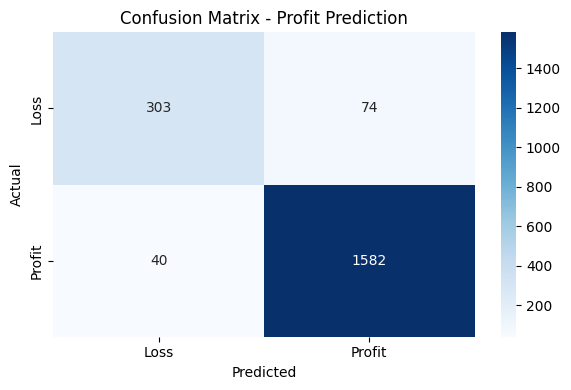

In [13]:
#Classification Report
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
             xticklabels=['Loss','Profit'],
             yticklabels=['Loss','Profit'])
plt.title("Confusion Matrix - Profit Prediction")
plt.ylabel('Actual')
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


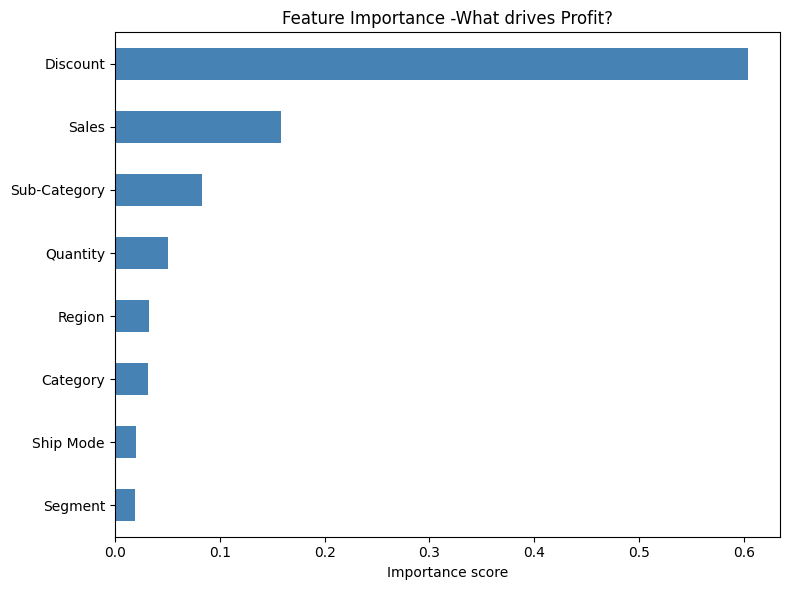


 Top Factors Affecting profitibality:
Discount: 0.604
Sales: 0.158
Sub-Category: 0.083
Quantity: 0.051
Region: 0.032
Category: 0.032
Ship Mode: 0.021
Segment: 0.019


In [14]:
# Feature Importance (Which Factor Affects Profit Most?)
plt.figure(figsize=(8,6))
importances=pd.Series(rf_model.feature_importances_,index=features)
importances.sort_values().plot(kind='barh',color='steelblue')
plt.title("Feature Importance -What drives Profit?")
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

print("\n Top Factors Affecting profitibality:")
for feat,imp in importances.sort_values(ascending=False).items():
  print(f"{feat}: {imp:.3f}")


In [16]:
#Buisness Summary of ML Results
accuracy=(y_pred==y_test).mean()*100
print("="*50)
print("ML Model - Buisness Summary")
print("="*50)
print(f"\n Model Accuracy :{accuracy:.1f}%")
print(f"\n Total Orders Tested : {len(y_test)}")
print(f"\n Correctly Predicted : {(y_pred==y_test).sum()}")

print("""
 Key Business Findings:

 1. Discount is the #1 factor killing profitability
    — Orders with 40%+ discount almost always lose money

 2. Sub-Category matters more than Category
    — Tables & Bookcases are consistent loss makers

 3. Technology products are safest to sell
    — Highest profit margin across all regions

 4. Sales Forecast shows strong Q4 seasonality
    — November-December peak every year
""")
print("=" * 55)


ML Model - Buisness Summary

 Model Accuracy :94.3%

 Total Orders Tested : 1999

 Correctly Predicted : 1885

 Key Business Findings:
 
 1. Discount is the #1 factor killing profitability
    — Orders with 40%+ discount almost always lose money
    
 2. Sub-Category matters more than Category
    — Tables & Bookcases are consistent loss makers
    
 3. Technology products are safest to sell
    — Highest profit margin across all regions
    
 4. Sales Forecast shows strong Q4 seasonality
    — November-December peak every year



In [18]:
# Export files for Power BI
df.to_csv('superstore_clean.csv', index=False)

# Export monthly sales for forecast chart
monthly_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
monthly_forecast.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
monthly_forecast.to_csv('sales_forecast.csv', index=False)

# Export feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
importance_df.to_csv('feature_importance.csv', index=False)

# Download all files
from google.colab import files
files.download('superstore_clean.csv')
files.download('sales_forecast.csv')
files.download('feature_importance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>